In [3]:
import json
from typing import List, Optional
from pydantic import BaseModel, Field
from enum import Enum
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI
import os
import pandas as pd
from groq import Groq
from langchain_groq import ChatGroq
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

/home/l0c4lh0st/Downloads/SpeakX_AURORA_2617/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [143]:
USER_BEHAVIOUR_INPUT_FILE = "user_behavioral_data.csv"
COMPANY_JSON_FILE = "./iteration_0_before_learning/brand_config.json"
KNOWLEDGE_BANK_FILE = "knowledge_bank.md"
RAW_CSV_PATH             =  USER_BEHAVIOUR_INPUT_FILE
FINAL_OUTPUT_PATH        = './iteration_0_before_learning/final_processed_dataset.csv'
api_key = "YOUR_API_KEY_HERE"

In [8]:
df=pd.read_csv(USER_BEHAVIOUR_INPUT_FILE)
db_col=df.columns.tolist()

## DATA INGESTION

In [9]:
REQUIRED_COLUMNS = df.columns.tolist()
ZSCORE_COLUMNS = [
    'days_since_signup', 'sessions_last_7d', 'exercises_completed_7d',
    'streak_current', 'coins_balance', 'preferred_hour',
]

INTEGER_COLUMNS = [
    'days_since_signup', 'sessions_last_7d', 'exercises_completed_7d',
    'streak_current', 'coins_balance', 'preferred_hour',
]

FLOAT_COLUMNS = ['notif_open_rate_30d', 'motivation_score']

BOOLEAN_FLAG_COLUMNS = [
    'feature_ai_tutor_used', 'feature_leaderboard_viewed', 'feature_progress_checked',
]

CATEGORICAL_COLUMNS   = ['lifecycle_stage']
VALID_LIFECYCLE_STAGES = {'trial', 'paid', 'churned', 'inactive'}

def validate_schema(df: pd.DataFrame) -> None:
    """
    Validate the schema of the raw DataFrame.

    Checks:
      1. All REQUIRED_COLUMNS are present.
      2. Integer/float columns are numeric.
      3. Boolean flags contain only {0, 1}.
      4. lifecycle_stage values are in the allowed set.

    Raises ValueError with a descriptive message on any failure.
    """
    # 1. Column presence
    missing_cols = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing_cols:
        raise ValueError(
            f"[STAGE A | validate_schema] Missing required column(s): {missing_cols}\n"
            f"  → Found: {list(df.columns)}"
        )

    # 2. Numeric columns
    for col in INTEGER_COLUMNS + FLOAT_COLUMNS:
        coerced = pd.to_numeric(df[col], errors='coerce')
        n_bad = coerced.isna().sum() - df[col].isna().sum()
        if n_bad > 0:
            raise ValueError(
                f"[STAGE A | validate_schema] Column '{col}' has {n_bad} non-numeric value(s)."
            )

    # 3. Boolean flags must be {0, 1}
    for col in BOOLEAN_FLAG_COLUMNS:
        bad = {v for v in df[col].dropna().unique() if v not in {0, 1, 0.0, 1.0}}
        if bad:
            raise ValueError(
                f"[STAGE A | validate_schema] Boolean column '{col}' has invalid values: {bad}"
            )

    # 4. lifecycle_stage categories
    raw_stages = df['lifecycle_stage'].dropna().str.strip().str.lower()
    unknown = set(raw_stages.unique()) - VALID_LIFECYCLE_STAGES
    if unknown:
        raise ValueError(
            f"[STAGE A | validate_schema] Unknown lifecycle_stage values: {unknown}\n"
            f"  → Valid: {VALID_LIFECYCLE_STAGES}"
        )


def clean_and_normalize(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # 1. Strip whitespace from object columns
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].astype(str).str.strip().replace('nan', pd.NA)

    # 2. Standardize lifecycle_stage
    df['lifecycle_stage'] = df['lifecycle_stage'].str.lower()
    print(f"  [clean] lifecycle_stage values: {sorted(df['lifecycle_stage'].dropna().unique())}")

    # 3. Remove duplicates
    n_before = len(df)
    df = df.drop_duplicates(subset='user_id', keep='first').reset_index(drop=True)
    removed = n_before - len(df)
    print(f"  [clean] Duplicate user_ids removed: {removed} | Remaining: {len(df)}")

    # 4 & 5. Clip rate columns
    df['notif_open_rate_30d'] = pd.to_numeric(df['notif_open_rate_30d'], errors='coerce').clip(0.0, 1.0)
    df['motivation_score']    = pd.to_numeric(df['motivation_score'],    errors='coerce').clip(0.0, 1.0)

    # 6. Fill missing numeric values with median
    for col in INTEGER_COLUMNS + FLOAT_COLUMNS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            if df[col].isna().any():
                median_val = df[col].median()
                n_filled   = df[col].isna().sum()
                df[col]    = df[col].fillna(median_val)
                print(f"  [clean] '{col}': filled {n_filled} NaN(s) with median={median_val:.4g}")

    # 7. Fill missing categorical values
    for col in CATEGORICAL_COLUMNS:
        if df[col].isna().any():
            df[col] = df[col].fillna(df[col].mode()[0])

    # 8 & 9. Type casting
    for col in INTEGER_COLUMNS:
        if col in df.columns:
            df[col] = df[col].round().astype(int)
    for col in FLOAT_COLUMNS:
        if col in df.columns:
            df[col] = df[col].astype(float)

    # 10. Encode lifecycle_stage as Categorical
    df['lifecycle_stage'] = pd.Categorical(
        df['lifecycle_stage'], categories=sorted(VALID_LIFECYCLE_STAGES), ordered=False
    )

    # 11. Boolean flags as int
    for col in BOOLEAN_FLAG_COLUMNS:
        if col in df.columns:
            df[col] = df[col].astype(int)

    df['lifecycle_stage'] = df['lifecycle_stage'].astype(str)

    # ── 1. Z-score normalize numeric columns ─────────────────

    for col in ZSCORE_COLUMNS:
        if col in df.columns:
            col_mean = df[col].mean()
            col_std  = df[col].std(ddof=0)
            if col_std == 0:
                print(f"'{col}' has zero std-dev — skipping normalization.")
            else:
                df[col] = (df[col] - col_mean) / col_std
                print(f"Z-scored '{col}' (mean={col_mean:.3f}, std={col_std:.3f})")

    # ── 2. One-hot encode lifecycle_stage ─────────────────────

    print("  [engineer] One-hot encoding lifecycle_stage...")
    lc_dummies = pd.get_dummies(df['lifecycle_stage'], prefix='lifecycle_stage').astype(int)

    # Ensure all 4 stage columns are present even if some are absent in data
    for stage in sorted(VALID_LIFECYCLE_STAGES):
        col_name = f'lifecycle_stage_{stage}'
        if col_name not in lc_dummies.columns:
            lc_dummies[col_name] = 0
    lc_dummies = lc_dummies[sorted(lc_dummies.columns)]

    # ── 3. One-hot encode age_band (if present) ───────────────

    ab_dummies = pd.DataFrame()
    if 'age_band' in df.columns:
        print("  [engineer] One-hot encoding age_band...")
        ab_dummies = pd.get_dummies(df['age_band'], prefix='age_band').astype(int)
        ab_dummies = ab_dummies[sorted(ab_dummies.columns)]

    # ── 4. One-hot encode region (if present) ─────────────────

    rg_dummies = pd.DataFrame()
    if 'region' in df.columns:
        print("  [engineer] One-hot encoding region...")
        rg_dummies = pd.get_dummies(df['region'], prefix='region').astype(int)
        rg_dummies = rg_dummies[sorted(rg_dummies.columns)]

    # ── 5. Drop original categorical columns ──────────────────

    cols_to_drop = ['lifecycle_stage']
    if 'age_band' in df.columns: cols_to_drop.append('age_band')
    if 'region'   in df.columns: cols_to_drop.append('region')
    df = df.drop(columns=cols_to_drop)

    # ── 6. Assemble in reference-file column order ────────────

    non_cat_cols = (
        ['user_id'] +
        ZSCORE_COLUMNS +
        BOOLEAN_FLAG_COLUMNS +
        FLOAT_COLUMNS
    )
    # Keep only columns that exist in df
    base_df = df[[c for c in non_cat_cols if c in df.columns]]

    # Concat in order: base | lifecycle OHE | age_band OHE | region OHE
    parts = [base_df, lc_dummies]
    if not ab_dummies.empty: parts.append(ab_dummies)
    if not rg_dummies.empty: parts.append(rg_dummies)

    final_df = pd.concat(parts, axis=1)

    print(f"\n[engineer_final_dataset] Done. Final shape: {final_df.shape}")
    print(f"   Columns: {list(final_df.columns)}")
    return final_df


# EXECUTION

# Step 1 — Load raw dataset
raw_df = pd.read_csv(RAW_CSV_PATH)

# Step 2 — Validate schema (fail-fast)
validate_schema(raw_df)

# Step 3 — Clean and normalize (intermediate)
final_df = clean_and_normalize(raw_df)
final_df.to_csv(FINAL_OUTPUT_PATH, index=False)

  [clean] lifecycle_stage values: ['churned', 'inactive', 'paid', 'trial']
  [clean] Duplicate user_ids removed: 0 | Remaining: 61
  [clean] 'coins_balance': filled 1 NaN(s) with median=112
Z-scored 'days_since_signup' (mean=50.426, std=44.473)
Z-scored 'sessions_last_7d' (mean=6.738, std=4.892)
Z-scored 'exercises_completed_7d' (mean=6.672, std=5.545)
Z-scored 'streak_current' (mean=8.262, std=8.714)
Z-scored 'coins_balance' (mean=175.836, std=165.902)
Z-scored 'preferred_hour' (mean=15.508, std=5.682)
  [engineer] One-hot encoding lifecycle_stage...
  [engineer] One-hot encoding age_band...
  [engineer] One-hot encoding region...

[engineer_final_dataset] Done. Final shape: (61, 22)
   Columns: ['user_id', 'days_since_signup', 'sessions_last_7d', 'exercises_completed_7d', 'streak_current', 'coins_balance', 'preferred_hour', 'feature_ai_tutor_used', 'feature_leaderboard_viewed', 'feature_progress_checked', 'notif_open_rate_30d', 'motivation_score', 'lifecycle_stage_churned', 'lifecycl

/tmp/ipykernel_52539/170285840.py:72: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


## KNOWLEDGE BANK ENGINE

In [ ]:

os.environ["GROQ_API_KEY"]=api_key
client = Groq()
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=api_key,
    temperature=0
)

class OctalysisDrive(str, Enum):
    EPIC_MEANING = "Epic Meaning"
    ACCOMPLISHMENT = "Accomplishment"
    EMPOWERMENT = "Empowerment"
    OWNERSHIP = "Ownership"
    SOCIAL_INFLUENCE = "Social Influence"
    SCARCITY = "Scarcity"
    UNPREDICTABILITY = "Unpredictability"
    LOSS_AVOIDANCE = "Loss Avoidance"

class GoalType(str, Enum):
    RETENTION = "Retention"
    CONVERSION = "Conversion"
    ENGAGEMENT = "Engagement"
    REACTIVATION = "Reactivation"

class MeasurableProxy(BaseModel):
    metric_name: str = Field(..., description="The leading indicator name")
    definition: str = Field(..., description="The exact mathematical definition of the proxy.")
    predictive_reasoning: str = Field(..., description="Explain why hitting this proxy statistically predicts success for the North Star Metric.")

class NorthStarMetric(BaseModel):
    metric_name: str = Field(..., description="The primary metric name ")
    definition: str = Field(..., description="The mathematical definition ")
    threshold_value: float = Field(..., description="The numeric threshold for success (e.g. 4.0)")
    measurable_proxy: MeasurableProxy = Field(..., description="The short-term leading indicator that predicts this North Star.")

class LifecycleStage(str, Enum):
    TRIAL = "Trial"
    PAID = "Paid"
    INACTIVE = "Inactive"
    CHURNED = "Churned"

class FeatureMap(BaseModel):
    feature_name: str
    db_col: str
    inferred_goal: GoalType
    octalysis_drive: OctalysisDrive
    target_lifecycle_stages: List[LifecycleStage] = Field(..., description="The user lifecycle stages where pushing this feature makes logical sense.")
    reasoning: str = Field(..., description="Why you mapped it this way.")
    # intentionally added reasoning to allow "Chain of thoughts" avoiding hallucinations

class HookTemplate(BaseModel):
    octalysis_drive: OctalysisDrive = Field(..., description="The specific Octalysis drive this hook triggers.")
    hook_name: str = Field(..., description="A catchy name for this hook strategy (e.g., 'The FOMO Nudge', 'The Hero's Call').")
    psychological_angle: str = Field(..., description="Why this hook works psychologically for the target audience.")

class ToneGuardrails(BaseModel):
    allowed_tones: List[str]
    disallowed_tones: List[str]
    safety_check_prompt: str = Field(..., description="A short system prompt to check if a message is safe.")

class BrandBrain(BaseModel):
    north_star: NorthStarMetric
    feature_mappings: List[FeatureMap]
    guardrails: ToneGuardrails
    hook_taxonomy: List[HookTemplate] = Field(..., description="A strategic list of copywriting hooks derived from the Octalysis framework.")


def extract_knowledge_bank(md_content: str,db_columns):

    system_prompt_template = """
    You are the 'Brain' of an automated marketing system.
    Your job is to parse the provided Company Knowledge Bank (Markdown) and extract structural rules.

    Here is the Company Knowledge Bank:
    {md_content}

    Here is the exact database columns list. USE ONLY THESE COLUMN NAMES TO MATCH TO FEATURES, USE OF ANY OTHER COLUMNS NAMES IS STRICTLY PROHIBITED
    {db_columns}

    CRITICAL RULES:
    1. Infer the 'North Star Metric' carefully. if it says metric>= 4 then the threshold value is 4.
    2. For 'Feature Mappings', analyze what user behavior the feature drives.
       - Example: 'Leaderboards' usually drive 'Social Influence' and 'Engagement'.
       - Example: 'Streaks' usually drive 'Loss Avoidance' and 'Retention'.
    3. Map the business features mentioned in the Knowledge Bank to the exact database columns provided above.
    4. GENERATE A HOOK TAXONOMY: For every unique Octalysis Drive identified in your Feature Mappings, generate 1 or 2 highly effective copywriting hooks.
       - Explain the psychological angle.
    5. For 'Guardrails', extract the exact adjectives used in the text.

    {format_instructions}
    """

    parser = PydanticOutputParser(pydantic_object=BrandBrain)

    prompt = PromptTemplate(
        template=system_prompt_template,
        input_variables=["md_content","db_columns"],
        partial_variables={"format_instructions": parser.get_format_instructions()},
    )

    chain = prompt | llm | parser

    try:
        validated_data = chain.invoke({"md_content": md_content,"db_columns":db_col})
        return validated_data
    except Exception as e:
        print(f"Validation Error: {e}")
        return None

try:
    with open(KNOWLEDGE_BANK_FILE, "r") as f:
        kb_text = f.read()

    brain_data = extract_knowledge_bank(kb_text,db_col)

    if brain_data:
        with open(COMPANY_JSON_FILE, "w") as f:
            f.write(brain_data.model_dump_json(indent=4))
        print("SUCCESS: 'brand_config.json' created successfully.")

except FileNotFoundError:
    print("Error: 'knowledge_bank.md' not found. Please create the file first.")

In [20]:
with open(COMPANY_JSON_FILE, 'r') as file:
    master_data = json.load(file)

# North Star Metric- justification, measurable proxy
north_star_file = {
    "north_star": master_data.get("north_star")
}
with open('./iteration_0_before_learning/company_north_star.json', 'w') as file:
    json.dump(north_star_file, file, indent=4)
print("Created: company_north_star.json")

# Feature Goal Mapping
feature_mapping_file = {
    "feature_mappings": master_data.get("feature_mappings")
}
with open('./iteration_0_before_learning/feature_goal_map.json', 'w') as file:
    json.dump(feature_mapping_file, file, indent=4)
print("Created: feature_goal_map.json")

# Tones and Hooks Taxonomy
tones_hooks_file = {
    "guardrails": master_data.get("guardrails"),
    "hook_taxonomy": master_data.get("hook_taxonomy")
}
with open('./iteration_0_before_learning/allowed_tone_hook_matrix.json', 'w') as file:
    json.dump(tones_hooks_file, file, indent=4)
print("Created: allowed_tone_hook_matrix.json")

Created: company_north_star.json
Created: feature_goal_map.json
Created: allowed_tone_hook_matrix.json


## SEGMENTATION AND CLUSTERING

In [22]:
df=pd.read_csv(FINAL_OUTPUT_PATH)
pd.set_option('display.max_columns', None)
df.head(5)

,user_id,days_since_signup,sessions_last_7d,exercises_completed_7d,streak_current,coins_balance,preferred_hour,feature_ai_tutor_used,feature_leaderboard_viewed,feature_progress_checked,notif_open_rate_30d,motivation_score,lifecycle_stage_churned,lifecycle_stage_inactive,lifecycle_stage_paid,lifecycle_stage_trial,age_band_18-24,age_band_25-34,age_band_35-44,region_tier1,region_tier2,region_tier3
0,US_1,1.541905,-0.355217,1.682269,1.576537,1.670646,-1.497450,0,0,1,0.304,0.65,0,0,1,0,0,1,0,0,1,0
1,US_2,1.699302,-1.377304,-1.203310,-0.948180,-1.029739,0.438560,0,0,1,0.111,0.37,1,0,0,0,0,1,0,0,1,0
2,US_3,-1.066395,0.462452,0.419828,-0.374380,-0.517389,-1.145449,0,1,1,0.435,0.51,0,0,0,1,0,1,0,0,1,0
3,US_4,-0.639174,0.053618,-0.121218,1.576537,-0.222035,-0.089443,0,1,1,0.483,0.77,0,0,1,0,1,0,0,1,0,0
4,US_5,1.496934,-1.377304,-1.203310,-0.948180,-0.951380,-1.145449,0,0,0,0.129,0.39,1,0,0,0,0,1,0,0,1,0


/home/l0c4lh0st/Downloads/SpeakX_AURORA_2617/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


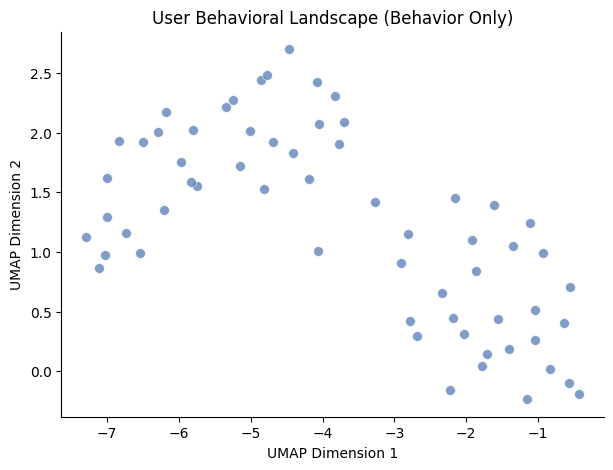

In [23]:
def reduce_dimensions_pipeline(df, feature_cols):
    """
    Executes a standard dimensionality reduction pipeline:
    Scaling -> PCA (Noise Reduction) -> UMAP (Non-linear mapping)
    """

    X = df[feature_cols].copy()
    pca = PCA(n_components=0.90, random_state=42)
    X_pca = pca.fit_transform(X)

    num_pca_components = X_pca.shape[1]

    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=20,
        min_dist=0.1,
        metric='euclidean',
        random_state=42
    )
    X_umap = reducer.fit_transform(X_pca)

    result_df = df.copy()
    result_df['umap_x'] = X_umap[:, 0]
    result_df['umap_y'] = X_umap[:, 1]

    return result_df
if __name__ == "__main__":
    features_to_reduce = df.columns.tolist()
    features_to_reduce.remove('user_id')
    # bansal
    # features_to_reduce = df[features_to_reduce].select_dtypes(include=['number']).columns.tolist()
    # df = df.dropna(subset=features_to_reduce)
    # bansal
    final_df = reduce_dimensions_pipeline(df, features_to_reduce)

    plt.figure(figsize=(7, 5))
    sns.scatterplot(
        x='umap_x',
        y='umap_y',
        data=final_df,
        alpha=0.7,
        s=50,
        color='#4C72B0'
    )

    plt.title("User Behavioral Landscape (Behavior Only)")
    plt.xlabel("UMAP Dimension 1")
    plt.ylabel("UMAP Dimension 2")
    sns.despine()
    plt.show()

Testing cluster sizes to find optimal K...
K=3 → Silhouette Score = 0.5795
K=4 → Silhouette Score = 0.4529
K=5 → Silhouette Score = 0.4546
K=6 → Silhouette Score = 0.3930

Optimal clusters: 3 (Score: 0.5795)


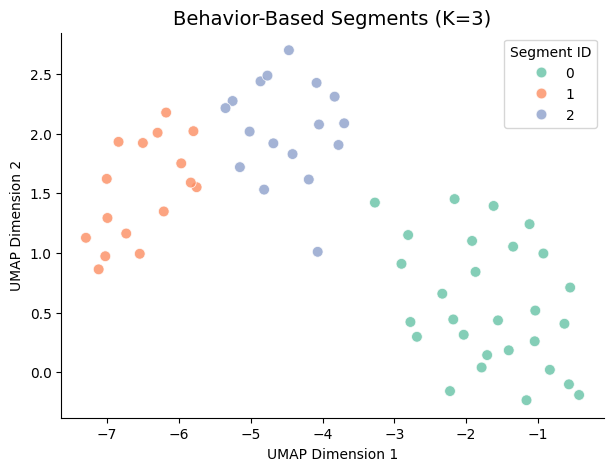

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

def exhaustive_clustering_pipeline(df, max_clusters=7):
    """
    Takes a DataFrame containing 'umap_x' and 'umap_y' (built ONLY from behavioral features),
    finds optimal K, and applies Agglomerative Clustering.
    """

    umap_coords = df[['umap_x', 'umap_y']].values

    best_k_min = 4
    best_score = -1
    scores = []

    print("Testing cluster sizes to find optimal K...")

    for k in range(3, max_clusters + 1):
        model = AgglomerativeClustering(n_clusters=k, linkage='ward')
        labels = model.fit_predict(umap_coords)

        score = silhouette_score(umap_coords, labels)
        scores.append(score)

        print(f"K={k} → Silhouette Score = {score:.4f}")

        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels

    print(f"\nOptimal clusters: {best_k} (Score: {best_score:.4f})")

    df = df.copy()
    df['segment_id'] = best_labels

    return df, best_k


# EXECUTION
clustered_df, optimal_k = exhaustive_clustering_pipeline(final_df, max_clusters=6)

# VISUALIZATION
plt.figure(figsize=(7, 5))
sns.scatterplot(
    x='umap_x',
    y='umap_y',
    hue='segment_id',
    palette='Set2',
    data=clustered_df,
    alpha=0.8,
    s=60
)

plt.title(f"Behavior-Based Segments (K={optimal_k})", fontsize=14)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(title='Segment ID')
sns.despine()
plt.show()

## UNIQUE FEATURES PER SEGMENT

In [26]:
def analyze_segments(df_normalized, df_raw=None, cluster_col='segment_id'):
    """
    Complete segment analysis tailored for an ALREADY NORMALIZED dataframe.
    Extracts top 3 positive and top 3 negative defining features.
    """

    ACTIONABLE_BEHAVIORS = [
        'sessions_last_7d',
        'exercises_completed_7d',
        'streak_current',
        'coins_balance',
        'feature_ai_tutor_used',
        'feature_leaderboard_viewed',
        'feature_progress_checked'
    ]

    if cluster_col not in df_normalized.columns:
        raise ValueError(f"Column '{cluster_col}' not found in df_normalized.")

    ignore_col=['user_id','umap_x','umap_y']
    features = [col for col in ACTIONABLE_BEHAVIORS]

    # Calculating means and standard deviations directly on the normalized data
    cluster_means_norm = df_normalized.groupby(cluster_col)[features].mean()
    overall_means_norm = df_normalized[features].mean()

    # Prevent division by zero if a feature is perfectly constant
    overall_std_norm = df_normalized[features].std().replace(0, 1e-9)

    # Calculate the Z-score matrix (How many standard deviations away from the global mean?)
    deviation_matrix = (cluster_means_norm - overall_means_norm) / overall_std_norm

    all_clusters_data = []

    for cluster_id in sorted(df_normalized[cluster_col].unique()):
        user_count = (df_normalized[cluster_col] == cluster_id).sum()
        user_pct = user_count / len(df_normalized) * 100

        # Get the deviations for this specific cluster
        deviations = deviation_matrix.loc[cluster_id]

        # Avoiding Negative Postive and Negative Features
        all_positives = deviations[deviations > 0].sort_values(ascending=False)
        all_negatives = deviations[deviations < 0].sort_values(ascending=True)

        if all_negatives.empty and not all_positives.empty:
            lowest_pos_idx = all_positives.index[-1]
            all_negatives = all_positives.tail(1)
            all_positives = all_positives.drop(lowest_pos_idx)

        # If there are NO positive features, steal the least negative feature
        elif all_positives.empty and not all_negatives.empty:
            least_neg_idx = all_negatives.index[-1]
            all_positives = all_negatives.tail(1)
            all_negatives = all_negatives.drop(least_neg_idx)

        # Get the top 3 positive and negative features
        top_positives = all_positives.head(3)
        top_negatives = all_negatives.head(3)

        # Helper function to print feature blocks
        def build_feature_list(feature_series, direction_label):
            features_data = []
            for rank, (feature, actual_dev) in enumerate(feature_series.items(), 1):
                if df_raw is not None and feature in df_raw.columns:
                    cluster_mask = (df_normalized[cluster_col].values == cluster_id)
                    # Cast pandas/numpy floats to standard Python floats for JSON serialization
                    cluster_val = float(df_raw[feature].values[cluster_mask].mean())
                    overall_val = float(df_raw[feature].mean())
                    unit = "(Raw)"
                else:
                    cluster_val = float(cluster_means_norm.loc[cluster_id, feature])
                    overall_val = float(overall_means_norm[feature])
                    unit = "(Normalized)"

                # features data for every segment
                features_data.append({
                    "rank": rank,
                    "feature": feature,
                    "direction": direction_label,
                    "cluster_mean": round(cluster_val, 2),
                    "overall_mean": round(overall_val, 2),
                    "deviation": round(float(actual_dev), 2),
                    "unit": unit
                })
            return features_data

        # Generate segment label based on the absolute highest deviation (positive or negative)
        highest_dev_feature = deviations.abs().idxmax()
        key_direction = "High" if deviations[highest_dev_feature] > 0 else "Low"
        suggested_label = f"{key_direction} {highest_dev_feature.replace('_', ' ').title()} Users"

        cluster_profile = {
            # Ensure cluster_id is standard int/string
            "cluster_id": int(cluster_id) if isinstance(cluster_id, (int, float)) else str(cluster_id),
            "suggested_label": suggested_label,
            "top_positive_features": build_feature_list(top_positives, "HIGH") if not top_positives.empty else [],
            "top_negative_features": build_feature_list(top_negatives, "LOW") if not top_negatives.empty else []
        }
        all_clusters_data.append(cluster_profile)

    return json.dumps(all_clusters_data,indent=4)

all_segments_data=analyze_segments(clustered_df, df_raw=df, cluster_col='segment_id')


## DEFINING TIMING WINDOWS PER SEGMENT

In [27]:
df_raw=pd.read_csv(USER_BEHAVIOUR_INPUT_FILE)
clustered_df['preferred_hour']=df_raw['preferred_hour']
clustered_df.head()

,user_id,days_since_signup,sessions_last_7d,exercises_completed_7d,streak_current,coins_balance,preferred_hour,feature_ai_tutor_used,feature_leaderboard_viewed,feature_progress_checked,notif_open_rate_30d,motivation_score,lifecycle_stage_churned,lifecycle_stage_inactive,lifecycle_stage_paid,lifecycle_stage_trial,age_band_18-24,age_band_25-34,age_band_35-44,region_tier1,region_tier2,region_tier3,umap_x,umap_y,segment_id
0,US_1,1.541905,-0.355217,1.682269,1.576537,1.670646,7,0,0,1,0.304,0.65,0,0,1,0,0,1,0,0,1,0,-1.345971,1.052066,0
1,US_2,1.699302,-1.377304,-1.203310,-0.948180,-1.029739,18,0,0,1,0.111,0.37,1,0,0,0,0,1,0,0,1,0,-7.004712,1.620312,1
2,US_3,-1.066395,0.462452,0.419828,-0.374380,-0.517389,9,0,1,1,0.435,0.51,0,0,0,1,0,1,0,0,1,0,-4.863546,2.437487,2
3,US_4,-0.639174,0.053618,-0.121218,1.576537,-0.222035,15,0,1,1,0.483,0.77,0,0,1,0,1,0,0,1,0,0,-2.900769,0.908102,0
4,US_5,1.496934,-1.377304,-1.203310,-0.948180,-0.951380,9,0,0,0,0.129,0.39,1,0,0,0,0,1,0,0,1,0,-6.840599,1.930578,1


In [29]:
# Mapping function
def map_hour_to_window(hour):
    if pd.isna(hour): return 'unknown'
    h = int(hour)
    if 6 <= h <= 9: return 'early_morning'
    elif 9 <= h <= 12: return 'mid_morning'
    elif 12 <= h <= 15: return 'afternoon'
    elif 15 <= h <= 18: return 'late_afternoon'
    elif 18 <= h <= 21: return 'evening'
    elif 21 <= h <= 24: return 'night'

# Expected CTR Fucntion
def generate_dynamic_ctr(user_preferred_hours, template_send_hours, max_ctr):
    """Simulates expected CTR based on traffic volume and statistical variance."""
    hour_counts = pd.Series(user_preferred_hours).value_counts()

    if hour_counts.empty:
        raise ValueError("User preferred hours data is empty.")

    peak_traffic_volume = hour_counts.max()
    estimated_ctrs = []

    for hour in template_send_hours:
        if hour not in hour_counts:
            base_ctr = 0.5
        else:
            # (Traffic for this hour / Peak Traffic) * Target Max CTR
            traffic_ratio = hour_counts[hour] / peak_traffic_volume
            base_ctr = traffic_ratio * max_ctr

        # Inject template quality variance (Normal distribution)
        final_ctr = np.random.normal(loc=base_ctr, scale=base_ctr * 0.15)
        final_ctr = max(0.01, final_ctr) # Prevent negative CTRs
        estimated_ctrs.append(round(final_ctr, 2))

    return estimated_ctrs

def calculate_expected_er(forecasted_ctrs, segment_data):
    """
    Calculates Engagement Rate strictly using the segment's historical
    usage of the target feature and their motivation score.
    """


    feature_prob = 1

    max_motivation = segment_data['motivation_score'].max()
    avg_motivation = segment_data['motivation_score'].mean()
    motivation_multiplier = avg_motivation / max_motivation if max_motivation > 0 else 1.0

    base_conversion_rate = feature_prob * motivation_multiplier

    estimated_ers = []

    for ctr in forecasted_ctrs:
        if ctr <= 0:
            estimated_ers.append(0.0)
            continue

        expected_er = ctr * base_conversion_rate
        final_er = np.random.normal(loc=expected_er, scale=expected_er * 0.15)
        final_er = max(0.01, min(final_er, ctr))

        estimated_ers.append(round(final_er, 2))

    return estimated_ers


print("Running Optimization Pipeline...")

clustered_df['timing_window'] = clustered_df['preferred_hour'].apply(map_hour_to_window)

# Calculate User Count and Resonance
window_analysis = clustered_df.groupby(['segment_id', 'timing_window']).agg(
    user_count=('user_id', 'count'),
    avg_open_rate=('notif_open_rate_30d', 'mean')
).reset_index()

# Calculate Expected Yield (The true tie-breaker for optimality)
window_analysis['expected_opens'] = window_analysis['user_count'] * window_analysis['avg_open_rate']

final_results = []

# Loop through each segment to find optimal times and generate CTR
for segment in clustered_df['segment_id'].unique():

    # Isolate segment raw data
    seg_raw_data = clustered_df[clustered_df['segment_id'] == segment]
    seg_user_hours = seg_raw_data['preferred_hour'].dropna()

    # Isolate segment window performance and get Top 3
    seg_windows = window_analysis[window_analysis['segment_id'] == segment]
    top_3_windows = seg_windows.sort_values(by='expected_opens', ascending=False).head(3)

    template_schedule = []
    window_names = []

    # Extract the exact peak hour for the winning windows
    for rank, row in enumerate(top_3_windows.itertuples(), 1):
        win_name = row.timing_window

        # Filter raw data to just the users active in this winning window
        hours_in_this_window = seg_raw_data[seg_raw_data['timing_window'] == win_name]['preferred_hour']

        if not hours_in_this_window.empty:
            exact_peak_hour = int(hours_in_this_window.mode().iloc[0])
        else:
            exact_peak_hour = 12 # Safe fallback

        template_schedule.append(exact_peak_hour)
        window_names.append((rank, win_name, exact_peak_hour))

    # Set the realistic ceiling for this specific segment's CTR
    # (If the segment averages 25% open rate, we cap max_ctr around 25)
    segment_max_ctr = seg_raw_data['notif_open_rate_30d'].mean() * 100

    # Generate the forecasted CTRs
    generated_ctrs = generate_dynamic_ctr(
        user_preferred_hours=seg_user_hours,
        template_send_hours=template_schedule,
        max_ctr=segment_max_ctr
    )

    generated_ers = calculate_expected_er(
        forecasted_ctrs=generated_ctrs,
        segment_data=seg_raw_data
    )

    # Store the results
    for i, (rank, win_name, anchor_hour) in enumerate(window_names):
        final_results.append({
            'segment_id': segment,
            'rank': rank,
            'timing_window': win_name,
            'anchor_hour': f"{anchor_hour:02d}:00",
            'expected_ctr': generated_ctrs[i],
            'expected_er': generated_ers[i]
        })


# Exporting
final_schedule_df = pd.DataFrame(final_results)

# Sort it neatly by Segment and then Rank
final_schedule_df = final_schedule_df.sort_values(by=['segment_id', 'rank']).reset_index(drop=True)
final_schedule_df.to_csv('./iteration_0_before_learning/timing_recommendations.csv', index=False)

Running Optimization Pipeline...


In [31]:
df=pd.read_csv('./iteration_0_before_learning/timing_recommendations.csv')
df.head()

,segment_id,rank,timing_window,anchor_hour,expected_ctr,expected_er
0,0,1,evening,19:00,46.08,28.42
1,0,2,late_afternoon,18:00,28.59,21.09
2,0,3,early_morning,07:00,23.36,15.26
3,1,1,early_morning,07:00,5.35,2.90
4,1,2,night,22:00,5.67,3.38


## ACTIVENESS,PROPENSITY SCORES AND CHURN RISK



In [32]:
def generate_segment_scores(df_normalized, feature_buckets, cluster_col='segment_id'):
    """
    Calculates Activeness, Propensity, and Churn Risk using Z-Scores,
    then normalizes the final output to a strict 0.0 to 1.0 scale.
    """

    if cluster_col not in df_normalized.columns:
        raise ValueError(f"Column '{cluster_col}' not found in df_normalized.")

    ignore_col = ['user_id', 'umap_x', 'umap_y','timing_window']

    # Only select numeric columns to prevent string/object crashing
    numeric_cols = df_normalized.select_dtypes(include=['number', 'bool']).columns
    features = [col for col in numeric_cols if col != cluster_col and col not in ignore_col]

    # Calculate the Z-score matrix
    cluster_means_norm = df_normalized.groupby(cluster_col)[features].mean()
    overall_means_norm = df_normalized[features].mean()
    overall_std_norm = df_normalized[features].std().replace(0, 1e-9)

    deviation_matrix = (cluster_means_norm - overall_means_norm) / overall_std_norm

    scores_df = pd.DataFrame(index=deviation_matrix.index)

    for score_name, feature_weights in feature_buckets.items():
        # keeping the features that exist in our deviation matrix
        valid_features = {f: w for f, w in feature_weights.items() if f in deviation_matrix.columns}

        if not valid_features:
            print(f"Warning: None of the features for {score_name} were found.")
            continue

        # the Directional Weights!
        # If a segment has high open_rate (+2 Z-score), but the weight is -1, it becomes -2
        weighted_z_scores = pd.DataFrame()
        for feature, weight in valid_features.items():
            weighted_z_scores[feature] = deviation_matrix[feature] * weight

        # Average the weighted Z-scores
        composite_z = weighted_z_scores.mean(axis=1)

        # Apply Sigmoid
        sigmoid_scores = 1 / (1 + np.exp(-composite_z))
        scores_df[f"{score_name}_Score"] = sigmoid_scores.round(2)

    return scores_df

# EXECUTION
# Giving directionaly weights in order to properly influence the score based on the features
# ( churn risk is inversely proportional to motivation_score)
scoring_logic = {
    "Activeness": {
        'sessions_last_7d': 1,
        'exercises_completed_7d': 1,
        'streak_current': 1,
        'notif_open_rate_30d': 1
    },
    "Propensity": {
        'streak_current': 1,
        'coins_balance': 1,
        'feature_leaderboard_viewed': 1,
        'feature_ai_tutor_used': 1,
        'motivation_score': 1
    },
    "Churn Risk": {
        'lifecycle_stage_inactive': 1,
        'lifecycle_stage_churned': 1,
        'notif_open_rate_30d': -1,
        'motivation_score': -1
    }
}

segment_scores_df = generate_segment_scores(clustered_df, scoring_logic, cluster_col='segment_id')
clustered_df = clustered_df.merge(
    segment_scores_df,
    left_on='segment_id',
    right_index=True,
    how='left'
)

In [34]:
final_segment_scores_df = segment_scores_df.reset_index()
file_name = './iteration_0_before_learning/user_segments.csv'
final_segment_scores_df.to_csv(file_name, index=False)

display(pd.read_csv(file_name).head())

,segment_id,Activeness_Score,Propensity_Score,Churn Risk_Score
0,0,0.68,0.65,0.38
1,1,0.23,0.28,0.78
2,2,0.48,0.46,0.41


## GOAL & JOURNEY BUILDER

In [35]:
CONFIG_PATH = COMPANY_JSON_FILE

if not os.path.exists(CONFIG_PATH):
    raise FileNotFoundError(
        f"'{CONFIG_PATH}' not found. "
        "Place brand_config.json in the same folder as this notebook, "
        "or update CONFIG_PATH above."
    )

with open(CONFIG_PATH, "r") as f:
    config = json.load(f)

assert "north_star"       in config, "Missing key: 'north_star'"
assert "feature_mappings" in config, "Missing key: 'feature_mappings'"
assert "metric_name"      in config["north_star"], "Missing key: north_star.metric_name"
assert "threshold_value"  in config["north_star"], "Missing key: north_star.threshold_value"
assert len(config["feature_mappings"]) > 0, "feature_mappings is empty"

for i, f in enumerate(config["feature_mappings"]):
    assert "feature_name"  in f, f"feature_mappings[{i}] missing 'feature_name'"
    assert "inferred_goal" in f, f"feature_mappings[{i}] missing 'inferred_goal'"


In [36]:
goals_present = list(dict.fromkeys(f["inferred_goal"] for f in config["feature_mappings"]))
print(f"inferred_goal values found in JSON: {goals_present}")

all_features = list(dict.fromkeys(f["feature_name"] for f in config["feature_mappings"]))

def extract(goal):
    """Return deduplicated list of feature_names where inferred_goal == goal."""
    seen = {}
    for f in config["feature_mappings"]:
        if f["inferred_goal"] == goal and f["feature_name"] not in seen:
            seen[f["feature_name"]] = True
    return list(seen.keys())

raw = {
    "Engagement"   : extract("Engagement"),
    "Retention"    : extract("Retention"),
    "Conversion"   : extract("Conversion"),
    "Reactivation" : extract("Reactivation"),
}

FALLBACK = {
    "Conversion"   : ["Retention",  "Engagement"],
    "Reactivation" : ["Engagement", "Retention"],
    "Retention"    : ["Engagement"],
    "Engagement"   : [],
}

def resolve(goal):
    """Return (feature_list, source_label) walking fallback chain until non-empty."""
    if raw[goal]:
        return raw[goal], goal
    for fb in FALLBACK.get(goal, []):
        if raw.get(fb):
            return raw[fb], f"{fb} [FALLBACK — '{goal}' not in JSON]"
    return all_features, "ALL [LAST RESORT FALLBACK]"

resolved = {g: resolve(g) for g in ["Engagement", "Retention", "Conversion", "Reactivation"]}

inferred_goal values found in JSON: ['Engagement', 'Retention', 'Conversion']


In [37]:
engagement_features  = resolved["Engagement"][0]
retention_features   = resolved["Retention"][0]
conversion_features  = resolved["Conversion"][0]
reactivation_features = resolved["Reactivation"][0]

# Sub-goals use feature slices from the resolved buckets
trial_subgoals = [
    {
        "day"           : "D0",
        "inferred_goal" : "Engagement",
        "sub_goal"      : "Complete first learning session — introduce all features",
        "features"      : all_features,  # push everything on day 0
        "success_metric": "Session 1 completed"
    },
    {
        "day"           : "D1",
        "inferred_goal" : "Engagement",
        "sub_goal"      : "Second session + first streak formed",
        "features"      : all_features,
        "success_metric": "Session 2 completed, streak = 2"
    },
    {
        "day"           : "D2",
        "inferred_goal" : "Engagement",
        "sub_goal"      : "Discover social and retention mechanics",
        "features"      : retention_features,  # spotlight retention features
        "success_metric": "User interacts with at least one retention feature"
    },
    {
        "day"           : "D3",
        "inferred_goal" : "Engagement",
        "sub_goal"      : "Deepen skill engagement via engagement features",
        "features"      : engagement_features,  # spotlight engagement features
        "success_metric": "Session 3 completed"
    },
    {
        "day"           : "D4",
        "inferred_goal" : "Engagement",
        "sub_goal"      : "Hit North Star — 4th session completes weekly target",
        "features"      : all_features,
        "success_metric": f"Session 4 completed → North Star ({config['north_star']['threshold_value']} sessions) achieved"
    },
    {
        "day"           : "D5",
        "inferred_goal" : "Engagement",
        "sub_goal"      : "Unlock first progress milestone",
        "features"      : engagement_features,
        "success_metric": "Milestone unlocked, progress visible to user"
    },
    {
        "day"           : "D6–D7",
        "inferred_goal" : "Conversion",
        "sub_goal"      : "Surface accumulated value and prompt upgrade to paid",
        "features"      : conversion_features,  # conversion bucket (with fallback)
        "success_metric": "Upgrade CTA clicked OR subscription started"
    },
]

In [38]:
retention_source = resolved["Retention"][1]  # shows fallback label if triggered

paid_subgoals = [
    {
        "week"          : "W2 (D8–D14)",
        "inferred_goal" : "Retention",
        "sub_goal"      : "Protect streak and anchor user in their league",
        "features"      : retention_features,
        "success_metric": "Streak maintained, league rank stable or improved"
    },
    {
        "week"          : "W3 (D15–D21)",
        "inferred_goal" : "Retention",
        "sub_goal"      : "Reduce friction at the mid-funnel drop-off point",
        "features"      : retention_features,
        "success_metric": f"Sessions/week >= {config['north_star']['threshold_value']}, continued engagement signals"
    },
    {
        "week"          : "W4 (D22–D30)",
        "inferred_goal" : "Retention",
        "sub_goal"      : "Surface milestone achievement and trigger renewal intent",
        "features"      : retention_features,
        "success_metric": "Renewal CTA clicked OR subscription auto-renewed"
    },
]

In [39]:
reactivation_source = resolved["Reactivation"][1]

churned_subgoals = [
    {
        "day"           : "Re-entry D1",
        "inferred_goal" : "Reactivation",
        "sub_goal"      : "Zero-pressure restart with one quick win",
        "features"      : reactivation_features,
        "success_metric": "1 session completed within 48h of re-entry push"
    },
    {
        "day"           : "Re-entry D2–D3",
        "inferred_goal" : "Reactivation",
        "sub_goal"      : "Surface past progress to remind user how far they came",
        "features"      : reactivation_features,
        "success_metric": "2nd session completed, past milestone surfaced"
    },
    {
        "day"           : "Re-entry D4+",
        "inferred_goal" : "Retention",
        "sub_goal"      : "Rebuild streak with no-penalty framing and re-anchor to league",
        "features"      : retention_features,
        "success_metric": f"New streak >= 3 days, {config['north_star']['metric_name']} week re-initiated"
    },
]

In [40]:
stages = [
    {
        "stage"      : "Trial",
        "days"       : "D0–D7",
        "goal"       : "Engagement → Conversion",
        "rule"       : "ALL features",
        "sub_goals"  : trial_subgoals,
        "day_key"    : "day"
    },
    {
        "stage"      : "Paid",
        "days"       : "D8–D30",
        "goal"       : "Retention",
        "rule"       : f"Retention features — {resolved['Retention'][1]}",
        "sub_goals"  : paid_subgoals,
        "day_key"    : "week"
    },
    {
        "stage"      : "Churned / Inactive",
        "days"       : "_",
        "goal"       : "Reactivation → Retention",
        "rule"       : f"Reactivation features — {resolved['Reactivation'][1]}",
        "sub_goals"  : churned_subgoals,
        "day_key"    : "day"
    },
]

fallbacks = [(g, src) for g, (_, src) in resolved.items() if src != g]

In [42]:
import csv, os

OUTPUT_PATH  = './iteration_0_before_learning/segment_goals.csv'
SEGMENTS_PATH = './iteration_0_before_learning/user_segments.csv'

# LOAD SEGMENTS (retrieve numerical segment_id, ignore segment_name)
if os.path.exists(SEGMENTS_PATH):
    with open(SEGMENTS_PATH, newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        segments = [
            row.get('segment_id', row.get('id', str(i)))
            for i, row in enumerate(reader)
        ]
else:
    segments = ['0', '1', '2', '3', '4', '5']

# Strip letters or 'SEG_' and just get the numerical ID
for i in range(len(segments)):
    num_str = ''.join(filter(str.isdigit, segments[i]))
    segments[i] = num_str if num_str else str(i)

# FLATTEN STAGES FROM PREVIOUS CELLS
stage_defs = []
for s in stages: # 'stages' is dynamically generated in earlier cells
    lifecycle = s['stage'].split()[0].lower() # 'Trial', 'Paid', 'Churned'
    p_goal    = s['goal']

    for sg in s['sub_goals']:
        day_label = sg.get('day', sg.get('week', ''))

        stage_defs.append({
            'lifecycle_stage'    : lifecycle,
            'day_label'          : day_label,
            'primary_goal'       : p_goal,
            'inferred_goal_type' : sg['inferred_goal'],
            'sub_goal'           : sg['sub_goal']
        })

# 3. WRITE segment_goals.csv
FIELDNAMES = [
    'segment_id',
    'lifecycle_stage', 'day_label',
    'primary_goal', 'inferred_goal_type', 'sub_goal'
]

rows_written = 0
with open(OUTPUT_PATH, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
    writer.writeheader()
    for seg_id in segments:
        for sd in stage_defs:
            writer.writerow({
                'segment_id'         : seg_id,
                'lifecycle_stage'    : sd['lifecycle_stage'],
                'day_label'          : sd['day_label'],
                'primary_goal'       : sd['primary_goal'],
                'inferred_goal_type' : sd['inferred_goal_type'],
                'sub_goal'           : sd['sub_goal']
            })
            rows_written += 1

print(f'segment_goals.csv written → {rows_written} rows')
df = pd.read_csv(OUTPUT_PATH)

segment_goals.csv written → 39 rows


## THEME ENGINE

In [43]:
file_path = COMPANY_JSON_FILE

# Converted JSON File into Dictionary
with open(file_path, 'r') as file:
    brand_config = json.load(file)

In [44]:
FEATURE_TO_DRIVE = {}

for item in brand_config["feature_mappings"]:
    feature_name = item["db_col"]
    drive_name = item["octalysis_drive"]
    FEATURE_TO_DRIVE[feature_name] = drive_name


FEATURE_TO_DRIVE_FALLBACK = {
    "sessions_last_7d": "Accomplishment",
    "exercises_completed_7d": "Accomplishment",
    "streak_current": "Loss Avoidance",
    "coins_balance": "Ownership",
    "feature_ai_tutor_used": "Empowerment",
    "feature_leaderboard_viewed": "Social Influence",
    "notif_open_rate_30d": "Unpredictability",
    "motivation_score": "Unpredictability"
  }

In [45]:
# Defining the Hooks For the Octolysis Drives
OCTALYSIS_HOOK_DIRECTIVES = {
    "Epic Meaning": "Frame the action as contributing to a grand mission, an elite group, or a larger purpose.",
    "Accomplishment": "Emphasize leveling up, mastering skills, hitting milestones, or overcoming specific challenges.",
    "Empowerment": "Highlight discovering new strategies, unlocking smarter tools, or validating their unique approach.",
    "Ownership": "Focus on accumulating rewards, claiming virtual assets, customizing profiles, or maximizing their stash.",
    "Social Influence": "Leverage peer comparison, rank climbing, community visibility, or defending social status.",
    "Scarcity": "Highlight exclusive access, limited-time windows, or restricted privileges they must earn.",
    "Unpredictability": "Tease mysteries, randomized rewards, or cliffhangers that compel immediate app opens.",
    "Loss Avoidance": "Drive urgency around protecting accumulated progress, preserving streaks, or preventing expired assets."
}

def build_segment_theme(segment_id, segment_analysis_data):

    # EXTRACT POSITIVE FEATURES PER SEGMENT
    pos_features = [
        item["feature"]
        for item in segment_analysis_data[segment_id].get("top_positive_features", [])
    ]

    # EXTRACT NEGATIVE FEATURES PER SEGMENT
    neg_features = [
        item["feature"]
        for item in segment_analysis_data[segment_id].get("top_negative_features", [])
    ]

    # EXTRACTING RESPECTIVE DRIVES FOR FEATURES
    pos_drives = [
      FEATURE_TO_DRIVE.get(f) if pd.notna(FEATURE_TO_DRIVE.get(f)) else FEATURE_TO_DRIVE_FALLBACK.get(f)
      for f in pos_features
    ]

    neg_drives = [
      FEATURE_TO_DRIVE.get(f) if pd.notna(FEATURE_TO_DRIVE.get(f)) else FEATURE_TO_DRIVE_FALLBACK.get(f)
      for f in neg_features
    ]

    primary_drive = pos_drives[0] if pos_drives else None
    secondary_drive = next((d for d in pos_drives[1:] if d != primary_drive), primary_drive)
    avoid_drive = neg_drives[0] if neg_drives else None

    allowed_tones = brand_config["guardrails"]["allowed_tones"]
    disallowed_tones = brand_config["guardrails"]["disallowed_tones"]

    # DEFINING THE THEME
    theme = {
        "segment_id": segment_id,
        "main_feature": pos_features[0],
        "primary_theme": primary_drive,
        "secondary_theme": secondary_drive,
        "avoid_theme": avoid_drive,
        "allowed_tones": allowed_tones,
        "disallowed_tones": disallowed_tones,
        "primary_hook":  OCTALYSIS_HOOK_DIRECTIVES[primary_drive],
        "secondary_hook": OCTALYSIS_HOOK_DIRECTIVES[secondary_drive],
    }

    return theme

In [47]:
# Export to CSV
segment_analysis_list = json.loads(all_segments_data)
all_themes_list = []
for s_id in range(len(segment_analysis_list)):

    current_theme = build_segment_theme(s_id, segment_analysis_list)
    all_themes_list.append(current_theme)

themes_df = pd.DataFrame(all_themes_list)
themes_df.to_csv('./iteration_0_before_learning/communication_themes.csv', index=False)

In [49]:
pd.read_csv('./iteration_0_before_learning/communication_themes.csv')

,segment_id,main_feature,primary_theme,secondary_theme,avoid_theme,allowed_tones,disallowed_tones,primary_hook,secondary_hook
0,0,coins_balance,Ownership,Loss Avoidance,Empowerment,"['Encouraging', 'Witty', 'Value-driven', 'Chal...","['Guilt-tripping', 'Manipulative', 'Overly agg...","Focus on accumulating rewards, claiming virtua...",Drive urgency around protecting accumulated pr...
1,1,feature_ai_tutor_used,Empowerment,Empowerment,Accomplishment,"['Encouraging', 'Witty', 'Value-driven', 'Chal...","['Guilt-tripping', 'Manipulative', 'Overly agg...","Highlight discovering new strategies, unlockin...","Highlight discovering new strategies, unlockin..."
2,2,sessions_last_7d,Accomplishment,Accomplishment,Ownership,"['Encouraging', 'Witty', 'Value-driven', 'Chal...","['Guilt-tripping', 'Manipulative', 'Overly agg...","Emphasize leveling up, mastering skills, hitti...","Emphasize leveling up, mastering skills, hitti..."


## TEMPLATE GENERATION

In [50]:
# DEFINING THE LIFECYCLE GOALS FOR EACH STAGE
LIFECYCLE_GOALS = {
    "lifecycle_stage_trial": "Conversion",
    "lifecycle_stage_paid": "Retention",
    "lifecycle_stage_inactive": "Reactivation",
    "lifecycle_stage_churned": "Win-back"
}

In [51]:
def get_system_prompt():
    """
    This is the static set of instructions, schema definitions,
    and few-shot examples that dictate HOW the LLM behaves.
    """

    return """You are an elite Growth Marketing AI. Your task is to ingest a JSON payload containing segment psychology and output exactly 5 notification templates in a strict JSON array which shows a gradual journey progression.

    --- ENGINEERING RULES ---
    1. VARIABLES: You MUST use the exact dynamic placeholders provided in the 'available_variables' array. Do not invent new ones.
    2. NARRATIVE VARIATION: Do not revolve exclusively around the 'main_feature'. Weave in the secondary themes and broader app value as the narrative progresses.
    3. TONE: Obey the 'allowed_tones' and 'disallowed_tones' strictly.
    4. PSYCHOLOGY: Frame each message exactly according to the 'hook_directive' specified for that stage.
    5. CONSTRAINTS:
      - 'message_title' MUST be under 40 characters.
      - 'message_body' MUST be under 120 characters.
      - 'cta_text' MUST be punchy and action-oriented (under 15 characters).
    6. HINGLISH REQUIREMENT: All '_hi' fields MUST be written in conversational "Hinglish" (a natural, relatable blend of Hindi and English written in the English/Latin alphabet. Example: "Streak tootne wali hai, wapas aao!"). Do not use formal or pure Hindi.
    7. OUTPUT FORMAT: Output MUST be a valid JSON array of exactly 5 objects following the exact schema below. Do not output any conversational text outside of the JSON array.

    --- REQUIRED OUTPUT SCHEMA ---
    [
      {
        "narrative_arc": "The stage name (e.g., T1_Seed, T2_Tease, etc.)",
        "message_title_en": "English notification title",
        "message_body_en": "English notification body text",
        "cta_text_en": "English CTA button text (e.g., 'Let's Go')",
        "message_title_hi": "Hinglish notification title",
        "message_body_hi": "Hinglish notification body text",
        "cta_text_hi": "Hinglish CTA button text (e.g., 'Chalo Shuru Karein')"
      }
      // ... repeat exactly for all 5 narrative stages
    ]
    """

def build_llm_user_payload(segment_theme, lifecycle_stage):
    """
    This is the dynamic data payload that changes for every Segment x Lifecycle loop.
    """
    return {
        "audience_context": {
            "segment_id": segment_theme["segment_id"],
            "lifecycle_state": lifecycle_stage,
            "main_feature": segment_theme["main_feature"],
            "campaign_goal": LIFECYCLE_GOALS[lifecycle_stage]
        },
        "psychological_framework": {
            "primary_theme": segment_theme["primary_theme"],
            "secondary_theme": segment_theme["secondary_theme"],
            "avoid_theme": segment_theme["avoid_theme"],
            "hook_directive": segment_theme["primary_hook"]
        },
        "guardrails": {
            "allowed_tones": segment_theme["allowed_tones"],
            "disallowed_tones": segment_theme["disallowed_tones"],
            "available_variables": [
                "{first_name}",
                "{streak_current}",
                "{coins_balance}",
                "{feature_name}"
            ]
        },
        "narrative_arc": {
            "T1_Seed": {
                "intensity": "Low",
                "execution_rule": "Use the 'secondary_drive' to plant an early idea. Do not mention the 'primary_drive' yet. Focus on curiosity."
            },
            "T2_Tease": {
                "intensity": "Medium",
                "execution_rule": "Transition to the 'primary_drive'. Build anticipation for the 'main_feature' without asking them to open the app yet."
            },
            "T3_Anchor": {
                "intensity": "MAX",
                "execution_rule": "Execute the 'hook_directive'. This is the hard push. Drive immediate action toward the 'campaign_goal'."
            },
            "T4_Welcome": {
                "intensity": "Positive",
                "execution_rule": "The user has opened the app. Drop the urgency. Validate their action and point them directly to the 'main_feature'."
            },
            "T5_WrapUp": {
                "intensity": "Low",
                "execution_rule": "Close the loop for the day. Do not use urgency. Summarize what they gained or learned, avoiding the 'avoid_drive'."
            }
        }
    }

In [52]:
import os
import time

GROQ_API_KEY = os.environ.get("GROQ_API_KEY")
client = Groq(api_key=GROQ_API_KEY)

def generate_segment_templates(client, segment_theme, lifecycle_stage):
    """
    Makes the API call to Groq for a specific Segment x Lifecycle combination.
    """
    system_prompt = get_system_prompt()
    user_payload = build_llm_user_payload(segment_theme, lifecycle_stage)

    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": json.dumps(user_payload, indent=2)}
            ],
            response_format={"type": "json_object"},
            temperature=0.7
        )
        response_data = json.loads(response.choices[0].message.content)

        return response_data if isinstance(response_data, list) else []

    except Exception as e:
        print(f"API Error for Segment {segment_theme['segment_id']}, Lifecycle {lifecycle_stage}: {e}")
        return []


parsed_segments_data = json.loads(all_segments_data)

segment_analysis_data = {
    str(cluster["cluster_id"]): cluster
    for cluster in parsed_segments_data
}

segment_ids = list(segment_analysis_data.keys())

# an empty list to store all our generated rows
def run_template_pipeline(segment_ids, segment_analysis_data):

    master_template_list = []
    lifecycles = ["lifecycle_stage_trial", "lifecycle_stage_paid", "lifecycle_stage_inactive", "lifecycle_stage_churned"]

    for segment_id in segment_ids:
        segment_theme = build_segment_theme(segment_id, segment_analysis_data)

        for lifecycle in lifecycles:
            print(f"Generating 5 templates for {segment_id} -> {lifecycle}...")

            # Calling the LLM
            templates = generate_segment_templates(client, segment_theme, lifecycle)

            for t in templates:
                master_template_list.append({
                    "segment_id": segment_id,
                    "lifecycle_stage": lifecycle,
                    "goal": LIFECYCLE_GOALS[lifecycle],
                    "template_id": f"{segment_id}_{lifecycle}_{t.get('narrative_arc')}",
                    "message_title_en": t.get("message_title_en"),
                    "message_body_en": t.get("message_body_en"),
                    "cta_text_en": t.get("cta_text_en"),
                    "message_title_hi": t.get("message_title_hi"),
                    "message_body_hi": t.get("message_body_hi"),
                    "cta_text_hi": t.get("cta_text_hi")
                })
            # For API rate limits
            time.sleep(1)

    # Convert to DataFrame
    return pd.DataFrame(master_template_list)

# Execution:
final_templates_df = run_template_pipeline(segment_ids,segment_analysis_data)

Generating 5 templates for 0 -> lifecycle_stage_trial...
Generating 5 templates for 0 -> lifecycle_stage_paid...
Generating 5 templates for 0 -> lifecycle_stage_inactive...
Generating 5 templates for 0 -> lifecycle_stage_churned...
Generating 5 templates for 1 -> lifecycle_stage_trial...
Generating 5 templates for 1 -> lifecycle_stage_paid...
Generating 5 templates for 1 -> lifecycle_stage_inactive...
Generating 5 templates for 1 -> lifecycle_stage_churned...
Generating 5 templates for 2 -> lifecycle_stage_trial...
Generating 5 templates for 2 -> lifecycle_stage_paid...
Generating 5 templates for 2 -> lifecycle_stage_inactive...
Generating 5 templates for 2 -> lifecycle_stage_churned...


In [56]:
final_templates_df.to_csv('./iteration_0_before_learning/message_templates.csv', index=False)

In [58]:
pd.read_csv('./iteration_0_before_learning/message_templates.csv').head()

,segment_id,lifecycle_stage,goal,template_id,message_title_en,message_body_en,cta_text_en,message_title_hi,message_body_hi,cta_text_hi
0,0,lifecycle_stage_trial,Conversion,0_lifecycle_stage_trial_T1_Seed,New Rewards,Curious about your rewards?,See,Naye Inaam,Kya aapke rewards hai?,Dekho
1,0,lifecycle_stage_trial,Conversion,0_lifecycle_stage_trial_T2_Tease,Coins Alert,Your coins balance is growing,Grow,Coins Alert,Aapke coins balance badh raha hai,Badhao
2,0,lifecycle_stage_trial,Conversion,0_lifecycle_stage_trial_T3_Anchor,Claim Now,Claim your {coins_balance} coins now,Claim,Abhi Claim Karein,Abhi apne {coins_balance} coins claim karein,Claim Karo
3,0,lifecycle_stage_trial,Conversion,0_lifecycle_stage_trial_T4_Welcome,Welcome Back,You're back! Check your {coins_balance} coins,Check,Swagat Hai,Aap wapas aa gaye! Apne {coins_balance} coins ...,Check Karo
4,0,lifecycle_stage_trial,Conversion,0_lifecycle_stage_trial_T5_WrapUp,Daily Recap,You earned {coins_balance} coins today,Done,Aaj Ka Recap,Aaj aapne {coins_balance} coins kamaye,Ho Gaya


## SCHEDULE GENERATOR

In [60]:
from datetime import datetime, timedelta

# Defining notification frequency according to the activeness score
def assign_frequency_tier(activeness_score, uninstall_rate):
    """Categorizes the user into 9, 5, or 3 notification tiers with guardrail override"""

    if activeness_score >= 0.7:
        base_tier = 9
    elif activeness_score >= 0.4:
        base_tier = 5
    else:
        base_tier = 3

    # 2. Apply the Guardrail Override
    if uninstall_rate >= 0.02:
        # Subtract 2, but ensure it never drops below a minimum of 1 notification
        return max(1, base_tier - 2)

    return base_tier

def generate_user_schedule(user_record):
    """
    Dynamically builds the daily schedule dictating exact times and
    channels based on the user's frequency tier.
    """
    user_id = user_record["user_id"]
    preferred_hour = int(user_record["preferred_hour"])
    activeness_score = float(user_record["Activeness_Score"])
    segment_id=user_record["segment_id"]

    # Default lifecycle stage
    lifecycle="Trial"
    total_notifs = assign_frequency_tier(activeness_score,0)

    lifecycle_map = {
        "lifecycle_stage_trial": "Trial",
        "lifecycle_stage_paid": "Paid",
        "lifecycle_stage_inactive": "Inactive",
        "lifecycle_stage_churned": "Churned"
    }

    for col_name, stage_string in lifecycle_map.items():
        if user_record.get(col_name) == 1:
            lifecycle = col_name
            break


    template_columns = [
        'message_title_en', 'message_body_en', 'cta_text_en',
        'message_title_hi', 'message_body_hi', 'cta_text_hi'
    ]
    templates_dict = final_templates_df.set_index('template_id')[template_columns].to_dict('index')

    # 2. Define your template IDs
    anchor_time = datetime.strptime(str(preferred_hour), "%H")
    t1_id = f"{segment_id}_{lifecycle}_T1_Seed"
    t2_id = f"{segment_id}_{lifecycle}_T2_Tease"
    t3_id = f"{segment_id}_{lifecycle}_T3_Anchor"
    t4_id = f"{segment_id}_{lifecycle}_T4_Welcome"
    t5_id = f"{segment_id}_{lifecycle}_T5_WrapUp"

    # 3. Create a clean Helper Function to extract data and handle fallbacks
    def get_template_data(t_id):
        tpl = templates_dict.get(t_id, {})
        return {
            "message_title_en": tpl.get("message_title_en"),
            "message_body_en": tpl.get("message_body_en"),
            "cta_text_en": tpl.get("cta_text_en"),
            "message_title_hi": tpl.get("message_title_hi"),
            "message_body_hi": tpl.get("message_body_hi"),
            "cta_text_hi": tpl.get("cta_text_hi")
        }

    # 4. Construct the beautiful, readable Slots dictionary
    slots = {
        # Morning / Pre-Anchor
        "T_minus_8": {"template_id": t1_id, "time": (anchor_time - timedelta(hours=8)).strftime("%H:%M"), "channel": "Email",  "template": get_template_data(t1_id)},
        "T_minus_4": {"template_id": t2_id, "time": (anchor_time - timedelta(hours=4)).strftime("%H:%M"), "channel": "Push",   "template": get_template_data(t2_id)},
        "T_minus_2": {"template_id": t1_id, "time": (anchor_time - timedelta(hours=2)).strftime("%H:%M"), "channel": "In-App", "template": get_template_data(t1_id)},

        # The Anchor / Peak Time
        "T_zero":    {"template_id": t3_id, "time": anchor_time.strftime("%H:%M"),"channel": "Push","template": get_template_data(t3_id)},

        # Post-Anchor / Session
        "T_plus_1m": {"template_id": t4_id, "time": (anchor_time + timedelta(minutes=1)).strftime("%H:%M"), "channel": "In-App", "template": get_template_data(t4_id)},
        "T_plus_15m":{"template_id": t4_id, "time": (anchor_time + timedelta(minutes=15)).strftime("%H:%M"),"channel": "In-App", "template": get_template_data(t4_id)},
        "T_plus_30m":{"template_id": t3_id, "time": (anchor_time + timedelta(minutes=30)).strftime("%H:%M"),"channel": "In-App", "template": get_template_data(t3_id)},

        # Evening / Wrap Up
        "T_plus_45m":{"template_id": t5_id, "time": (anchor_time + timedelta(minutes=45)).strftime("%H:%M"),"channel": "In-App", "template": get_template_data(t5_id)},
        "T_plus_2h": {"template_id": t5_id, "time": (anchor_time + timedelta(hours=2)).strftime("%H:%M"),   "channel": "Email",  "template": get_template_data(t5_id)}
    }
    schedule = []

    # Dynamically selecting the notif_1 to notif_9 according to the frequency
    if total_notifs == 9:
        schedule = [
            slots["T_minus_8"], slots["T_minus_4"], slots["T_minus_2"],
            slots["T_zero"], slots["T_plus_1m"], slots["T_plus_15m"],
            slots["T_plus_30m"], slots["T_plus_45m"], slots["T_plus_2h"]
        ]
    elif total_notifs == 5:
        schedule = [
            slots["T_minus_4"], slots["T_minus_2"],slots["T_zero"],
            slots["T_plus_15m"], slots["T_plus_2h"]
        ]
    elif total_notifs == 3:
        schedule = [
            slots["T_minus_2"],slots["T_zero"], slots["T_plus_2h"]
        ]

    # Pad the rest with NULLs so the database array is exactly 9 items long
    while len(schedule) < 9:
        schedule.append(None)

    user_output = {
        "user_id": user_id,
        "segment_id": user_record.get("segment_id", "Unknown"),
        "lifecycle_day": lifecycle,
        "tier": total_notifs

    }
    # Dynamically inject notif_1 through notif_9
    for i in range(9):
        user_output[f"notif_{i+1}"] = schedule[i]

    return user_output

In [61]:

raw_dataset = clustered_df.to_dict(orient='records')
# Iterate through the dataset and build the master schedule
master_schedule = []
for row in raw_dataset:
    user_schedule = generate_user_schedule(row)
    master_schedule.append(user_schedule)



flat_schedule = []

for user_data in master_schedule:
    # Loop through all 9 possible notification slots for the user
    for i in range(1, 10):
        notif_key = f"notif_{i}"
        notif_info = user_data.get(notif_key)

        # If the slot is not empty (None), extract the exact columns
        if notif_info is not None:
            flat_schedule.append({
                "user_id": user_data["user_id"],
                "segment_id": user_data["segment_id"],
                "lifecycle_day": user_data["lifecycle_day"],
                "total_notif": user_data["tier"],
                "notification": notif_key,
                "time": notif_info["time"],
                "channel": notif_info["channel"],
                "message_title_en": notif_info["template"]["message_title_en"],
                "message_body_en": notif_info["template"]["message_body_en"],
                "cta_text_en": notif_info["template"]["cta_text_en"],
                "message_title_hi": notif_info["template"]["message_title_hi"],
                "message_body_hi": notif_info["template"]["message_body_hi"],
                "cta_text_hi": notif_info["template"]["cta_text_hi"],
            })

final_schedule_df_copy = pd.DataFrame(flat_schedule)
final_schedule_df_copy.to_csv('./iteration_0_before_learning/user_notification_schedule.csv', index=False)

print("Saved successfully: ./iteration_0_before_learning/user_notification_schedule.csv")

Saved successfully: ./iteration_0_before_learning/user_notification_schedule.csv


In [62]:
pd.read_csv('./iteration_0_before_learning/user_notification_schedule.csv')

,user_id,segment_id,lifecycle_day,total_notif,notification,time,channel,message_title_en,message_body_en,cta_text_en,message_title_hi,message_body_hi,cta_text_hi
0,US_1,0,lifecycle_stage_paid,5,notif_1,03:00,Push,Coins Alert,Your {coins_balance} is growing!,Grow,Coins Alert,Aapka {coins_balance} badh raha hai!,Badhao
1,US_1,0,lifecycle_stage_paid,5,notif_2,05:00,In-App,New,What's hiding in your {feature_name}?,See,Naya,Aapke {feature_name} mein kya chupa hai?,Dekho
2,US_1,0,lifecycle_stage_paid,5,notif_3,07:00,Push,Claim Now,Get more {coins_balance} & customize your prof...,Claim,Abhi Claim Karo,"Aur {coins_balance} kamao, apna profile custom...",Claim Karo
3,US_1,0,lifecycle_stage_paid,5,notif_4,07:15,In-App,You're Back,Welcome to your {feature_name}! Check your {co...,Go,Aap Wapas,Aapka {feature_name}! Aapka {coins_balance} de...,Chalo
4,US_1,0,lifecycle_stage_paid,5,notif_5,09:00,Email,Daily Recap,You earned {coins_balance} today!,Done,Aaj Ka Recap,Aaj aapne {coins_balance} kamaya!,Ho Gaya
...,...,...,...,...,...,...,...,...,...,...,...,...,...
268,US_61,0,lifecycle_stage_paid,5,notif_1,08:00,Push,Coins Alert,Your {coins_balance} is growing!,Grow,Coins Alert,Aapka {coins_balance} badh raha hai!,Badhao
269,US_61,0,lifecycle_stage_paid,5,notif_2,10:00,In-App,New,What's hiding in your {feature_name}?,See,Naya,Aapke {feature_name} mein kya chupa hai?,Dekho
270,US_61,0,lifecycle_stage_paid,5,notif_3,12:00,Push,Claim Now,Get more {coins_balance} & customize your prof...,Claim,Abhi Claim Karo,"Aur {coins_balance} kamao, apna profile custom...",Claim Karo
271,US_61,0,lifecycle_stage_paid,5,notif_4,12:15,In-App,You're Back,Welcome to your {feature_name}! Check your {co...,Go,Aap Wapas,Aapka {feature_name}! Aapka {coins_balance} de...,Chalo


## LEARNING PHASE

In [70]:
GOOD_CTR = 15.0
GOOD_ENGAGEMENT = 40.0
BAD_CTR = 5.0
BAD_ENGAGEMENT = 20.0

INPUT_FILE = 'experiment_results.csv'
OUTPUT_FILE = 'classified_output.csv'

#### UPDATED TIMING RECOMMENDATIONS

In [123]:
# Finding the optimal timing windows
def learn_optimal_timing_strictly(csv_path):
    df = pd.read_csv(csv_path)

    # Classification based on the rules given
    def classify(row):
        if row['ctr'] > GOOD_CTR and row['engagement_rate'] > GOOD_ENGAGEMENT:
            return 'GOOD'
        elif row['ctr'] < BAD_CTR and row['engagement_rate'] < BAD_ENGAGEMENT:
            return 'BAD'
        else:
            return 'NEUTRAL'

    df['performance_status'] = df.apply(classify, axis=1)

    optimal_timing_map = {}

    # Finding the optimal window per segment based purely on Win Rate
    for segment in df['segment_id'].unique():
        seg_data = df[df['segment_id'] == segment]

        # Calculating what percentage of templates in each window achieved "Good" status
        window_stats = seg_data.groupby('notification_window')['performance_status'].apply(
            lambda x: (x == 'GOOD').mean() * 100
        ).reset_index(name='good_hit_rate_pct')

        # The optimal window is simply the one with the highest mathematical probability of being "Good"
        top_windows = window_stats.sort_values(by='good_hit_rate_pct', ascending=False).head(3)

        windows_list = []
        
        # 3. Iterate through the top windows safely
        for rank, row in enumerate(top_windows.itertuples(), 1):
            windows_list.append({
                'rank': rank,
                'optimal_window': row.notification_window,
                'success_probability': float(round(row.good_hit_rate_pct, 1))
            })

        optimal_timing_map[int(segment)] = {
            'segment_id': int(segment),
            'top_windows': windows_list
        }

    return optimal_timing_map

In [ ]:
optimal_timing_map=learn_optimal_timing_strictly(INPUT_FILE)
optimal_timing_map

In [ ]:
new_final_results = []

# Loop directly through the mathematically proven winners instead of raw volume
for segment_id, learned_data in optimal_timing_map.items():
    segment = int(segment_id)

    # Isolate segment raw data
    seg_raw_data = clustered_df[clustered_df['segment_id'] == segment]
    seg_user_hours = seg_raw_data['preferred_hour'].dropna()

    template_schedule = []
    window_names = []

    # Extract the exact peak hour for the NEW winning windows
    for window_info in learned_data['top_windows']:
        rank = window_info['rank']
        win_name = window_info['optimal_window'] # e.g., 'evening'

        # Filter raw data to just the users active in this specific winning window
        hours_in_this_window = seg_raw_data[seg_raw_data['timing_window'] == win_name]['preferred_hour']

        if not hours_in_this_window.empty:
            exact_peak_hour = int(hours_in_this_window.mode().iloc[0])
        else:
            exact_peak_hour = 12 # Safe fallback if no users naturally sit in this window

        template_schedule.append(exact_peak_hour)
        window_names.append((rank, win_name, exact_peak_hour))

    # Set the realistic ceiling for this specific segment's CTR
    segment_max_ctr = seg_raw_data['notif_open_rate_30d'].mean() * 100

    # Generate the forecasted CTRs for these new hours
    generated_ctrs = generate_dynamic_ctr(
        user_preferred_hours=seg_user_hours,
        template_send_hours=template_schedule,
        max_ctr=segment_max_ctr
    )

    # Generate the forecasted ERs based on those CTRs
    generated_ers = calculate_expected_er(
        forecasted_ctrs=generated_ctrs,
        segment_data=seg_raw_data
    )

    # Store the results
    for i, (rank, win_name, anchor_hour) in enumerate(window_names):
        new_final_results.append({
            'segment_id': segment,
            'rank': rank,
            'timing_window': win_name,
            'anchor_hour': f"{anchor_hour:02d}:00",
            'expected_ctr': generated_ctrs[i],
            'expected_er': generated_ers[i]
        })

# Exporting the Updated Recommendations
new_schedule_df = pd.DataFrame(new_final_results)

# Sort it neatly by Segment and then Rank
new_schedule_df = new_schedule_df.sort_values(by=['segment_id', 'rank']).reset_index(drop=True)

# Dynamically create the folder and save the new CSV
output_path = './iteration_1_after_learning/timing_recommendations.csv'
# os.makedirs(os.path.dirname(output_path), exist_ok=True)
new_schedule_df.to_csv(output_path, index=False)

print("Iteration 1 Timing Recommendations generated and saved!")
new_schedule_df.head()

#### UPDATED MESSAGE TEMPLATES

In [ ]:
# Learning optimal theme
def learn_optimal_theme_strictly(csv_path):
    df = pd.read_csv(csv_path)

    def classify(row):
        if row['ctr'] > GOOD_CTR and row['engagement_rate'] > GOOD_ENGAGEMENT:
            return 'GOOD'
        elif row['ctr'] < BAD_CTR and row['engagement_rate'] < BAD_ENGAGEMENT:
            return 'BAD'
        else:
            return 'NEUTRAL'

    # Apply classification (if it hasn't been applied already)
    if 'performance_status' not in df.columns:
        df['performance_status'] = df.apply(classify, axis=1)

    optimal_theme_map = {}

    # Finding the optimal theme per segment based purely on Win Rate
    for segment in df['segment_id'].unique():
        seg_data = df[df['segment_id'] == segment]

        # 1. Group by 'theme' instead of 'notification_window'
        theme_stats = seg_data.groupby('theme')['performance_status'].apply(
            lambda x: (x == 'GOOD').mean() * 100
        ).reset_index(name='good_hit_rate_pct')

        # 2. Sort all themes by success rate (highest to lowest) and grab the Top 3
        top_themes = theme_stats.sort_values(by='good_hit_rate_pct', ascending=False).head(3)

        themes_list = []
        
        # 3. Iterate through the top themes safely
        for rank, row in enumerate(top_themes.itertuples(), 1):
            themes_list.append({
                'rank': rank,
                'optimal_theme': row.theme,
                'success_probability': float(round(row.good_hit_rate_pct, 1))
            })

        # 4. Store the structured list of top themes for this segment
        optimal_theme_map[int(segment)] = {
            'segment_id': int(segment),
            'top_themes': themes_list
        }

    return optimal_theme_map

In [ ]:
# --- Execution Example ---
optimal_theme_map = learn_optimal_theme_strictly('experiment_results.csv')
print(optimal_themes[1]) # Print the top themes for Segment 1

In [ ]:
# 1. The Modified LLM Caller
def generate_learned_templates(client, segment_theme, lifecycle_stage, optimal_theme):
    """
    Makes the API call to Groq, injecting the mathematically proven Optimal Theme.
    """
    system_prompt = get_system_prompt()
    user_payload = build_llm_user_payload(segment_theme, lifecycle_stage)
    
    # --- THE LEARNING LOOP OVERRIDE ---
    # We dynamically append this strict instruction to the end of the system prompt
    learning_directive = (
        f"\n\n--- CRITICAL LEARNING LOOP OVERRIDE ---\n"
        f"A/B testing has mathematically proven that this specific user segment responds "
        f"best to the '{optimal_theme}' psychological theme. You MUST center the narrative arc, "
        f"hooks, and CTA of all 5 templates heavily around '{optimal_theme}'. Do not use generic hooks."
    )
    system_prompt += learning_directive

    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": json.dumps(user_payload, indent=2)}
            ],
            response_format={"type": "json_object"},
            temperature=0.7 # Keeps it creative but obedient
        )
        response_data = json.loads(response.choices[0].message.content)

        # Handle Groq JSON object vs array formatting
        if isinstance(response_data, dict) and "templates" in response_data:
            return response_data["templates"]
        elif isinstance(response_data, list):
            return response_data
        else:
            # Fallback if the LLM wraps it weirdly
            return list(response_data.values())[0] if isinstance(response_data, dict) else []

    except Exception as e:
        print(f"API Error for Segment {segment_theme['segment_id']}, Lifecycle {lifecycle_stage}: {e}")
        return []

# 2. The Updated Main Loop
def run_learned_template_pipeline(segment_ids, segment_analysis_data, optimal_theme_map):

    master_template_list = []
    lifecycles = ["lifecycle_stage_trial", "lifecycle_stage_paid", "lifecycle_stage_inactive", "lifecycle_stage_churned"]

    for segment_id in segment_ids:
        segment_theme = build_segment_theme(segment_id, segment_analysis_data)
        
        # --- EXTRACT THE LEARNED THEME ---
        # Safely pull the Rank 1 theme for this specific segment from the map we built earlier
        learned_data = optimal_theme_map.get(int(segment_id), {})
        top_themes = learned_data.get('top_themes', [])
        
        if top_themes:
            optimal_theme = top_themes[0]['optimal_theme'] # Grab the #1 winner
        else:
            optimal_theme = "General" # Fallback if no A/B test data exists yet

        for lifecycle in lifecycles:
            print(f"Generating templates for Seg {segment_id} -> {lifecycle} | Theme: {optimal_theme}...")

            # Call the new LLM function, passing the optimal_theme
            templates = generate_learned_templates(client, segment_theme, lifecycle, optimal_theme)

            for t in templates:
                if not isinstance(t, dict): continue # Safety check
                
                master_template_list.append({
                    "segment_id": segment_id,
                    "lifecycle_stage": lifecycle,
                    "goal": LIFECYCLE_GOALS[lifecycle],
                    "theme_used": optimal_theme,  # NEW: Log this so you can track it in the DB!
                    "template_id": f"{segment_id}_{lifecycle}_{t.get('narrative_arc')}",
                    "message_title_en": t.get("message_title_en"),
                    "message_body_en": t.get("message_body_en"),
                    "cta_text_en": t.get("cta_text_en"),
                    "message_title_hi": t.get("message_title_hi"),
                    "message_body_hi": t.get("message_body_hi"),
                    "cta_text_hi": t.get("cta_text_hi")
                })
            # Respect API rate limits
            time.sleep(1)

    return pd.DataFrame(master_template_list)

# --- Execution ---
final_learned_templates_df = run_learned_template_pipeline(segment_ids, segment_analysis_data, optimal_theme_map)
final_learned_templates_df.to_csv('./iteration_1_after_learning/message_templates.csv', index=False)

#### CAUSAL EXPLAINATION

In [ ]:
def calculate_bayesian_optimality(csv_df, min_reliable_sample=10):
    """
    Uses Empirical Bayes to find the optimal Notification Window, Goal, and Theme 
    per segment, protecting against small sample size illusions.
    """
    # Calculate Granular Performance (The "Triplet")
    triplet_stats = csv_df.groupby(['segment_id', 'notification_window', 'goal', 'theme']).agg(
        triplet_volume=('template_id', 'count'),
        triplet_successes=('performance_status', lambda x: (x == 'GOOD').sum())
    ).reset_index()
    
    triplet_stats['triplet_win_rate'] = triplet_stats['triplet_successes'] / triplet_stats['triplet_volume']

    # Calculate Broad Performance (The "Prior" / Goal)
    goal_stats = csv_df.groupby(['segment_id', 'goal']).agg(
        goal_volume=('template_id', 'count'),
        goal_successes=('performance_status', lambda x: (x == 'GOOD').sum())
    ).reset_index()
    
    goal_stats['goal_win_rate'] = goal_stats['goal_successes'] / goal_stats['goal_volume']

    # Merge and Apply Bayesian Shrinkage
    merged = triplet_stats.merge(
        goal_stats[['segment_id', 'goal', 'goal_win_rate']],
        on=['segment_id', 'goal'], 
        how='left'
    )

    # K represents our confidence in the data (0.0 to 1.0)
    merged['credibility_weight'] = merged['triplet_volume'] / (merged['triplet_volume'] + min_reliable_sample)

    # Shrunk Score pulls low-volume outliers toward the average
    merged['bayesian_win_rate'] = (
        (merged['credibility_weight'] * merged['triplet_win_rate']) +
        ((1 - merged['credibility_weight']) * merged['goal_win_rate'])
    )

    # Format Output for Maximum Comprehensibility
    optimal_configs_display = []
    optimal_configs_dict = {}
    
    for segment in merged['segment_id'].unique():
        seg_data = merged[merged['segment_id'] == segment]
        
        # Sort to find the absolute best combination for this segment
        best_row = seg_data.sort_values(by='bayesian_win_rate', ascending=False).iloc[0]
        
        # DataFrame format for display
        optimal_configs_display.append({
            'Segment': str(segment),
            'Optimal Window': best_row['notification_window'],
            'Optimal Goal': best_row['goal'],
            'Optimal Theme': best_row['theme'],
            'Bayesian Win Rate': f"{best_row['bayesian_win_rate'] * 100:.2f}%",
            'Raw Triplet Win Rate': f"{best_row['triplet_win_rate'] * 100:.2f}%",
            'Data Credibility (K)': f"{best_row['credibility_weight'] * 100:.1f}%",
            'Total Sends (Volume)': int(best_row['triplet_volume'])
        })

        # FIX 2: Safely cast segment to int so dictionary lookups don't fail
        segment_key = int(segment)
        optimal_configs_dict[segment_key] = {
            'window': best_row['notification_window'],
            'final_score': best_row['bayesian_win_rate'],
            'goal': best_row['goal'],
            'n_triplet': int(best_row['triplet_volume']),
            'theme': best_row['theme'],
            'sr_goal': best_row['goal_win_rate'],
            'credibility_K': best_row['credibility_weight'],
            'sr_triplet': best_row['triplet_win_rate'],
        }
        
    # FIX 1: This MUST be outdented to happen AFTER the loop finishes
    return pd.DataFrame(optimal_configs_display), optimal_configs_dict


def generate_ab_test_hypotheses(csv_df, optimal_configs, min_reliable_sample=10):
    """
    Generates Delta Reports specifically framed as A/B Test Hypotheses.
    Uses the Bayesian metrics to justify WHY the test is being run.
    """
    delta_reports = []
    target_df = csv_df[csv_df['performance_status'] == 'NEUTRAL']

    for _, row in target_df.iterrows():
        # FIX 3: Cast lookup key to int to match the dictionary
        segment = int(row['segment_id']) 
        
        if segment not in optimal_configs:
            continue

        gold = optimal_configs[segment]

        current_config = (row['notification_window'], row['goal'], row['theme'])
        optimal_config = (gold['window'], gold['goal'], gold['theme'])

        is_config_change = (current_config != optimal_config)

        if is_config_change:
            change_type = "AB_Test_Config_Shift"
            k_factor = gold['credibility_K']
            triplet_sr = gold['sr_triplet']
            goal_sr = gold['sr_goal']
            n_samples = gold['n_triplet']
            
            # Prevent Division by Zero if current CTR is 0
            current_ctr = row['ctr'] / 100 if row['ctr'] > 0 else 0.001 
            projected_lift = ((gold['final_score'] - current_ctr) / current_ctr) * 100

            if k_factor >= 0.5:
                causal_reasoning = (
                    f"Historical data provides strong direct evidence (n={n_samples}, credibility={k_factor:.0%}) "
                    f"that the target configuration ({gold['window']}, {gold['goal']}) outperforms the current setup. "
                    f"The specific combination has a observed success rate of {triplet_sr:.1%}. "
                    f"We hypothesize that aligning to this proven pattern will yield a {projected_lift:.1f}% lift in CTR."
                )
            else:
                causal_reasoning = (
                    f"Direct data for this specific combination is sparse (n={n_samples}, credibility={k_factor:.0%}), "
                    f"preventing reliance on triplet history alone. HOWEVER, strong component-level intersection exists: "
                    f"the goal '{gold['goal']}' demonstrates a robust {goal_sr:.1%} success rate across the segment. "
                    f"We hypothesize that leveraging this high-performing component within the '{gold['window']}' context "
                    f"will unlock similar gains, despite the limited direct triplet samples."
                )

            before_val = f"W:{row['notification_window']}|G:{row['goal']} (CTR: {row['ctr']}%)"
            after_val = f"W:{gold['window']}|G:{gold['goal']} (Target Score: {gold['final_score']:.2f})"
            metric_trigger = f"Status: NEUTRAL | Current CTR: {row['ctr']}% | Projected Lift: {projected_lift:.1f}%"

        else:
            change_type = "AB_Test_Copy_Iteration"
            causal_reasoning = (
                f"The current configuration matches the statistically optimal pattern (Score: {gold['final_score']:.2f}). "
                f"Since the parameters are correct but performance is only 'Neutral', we hypothesize that "
                f"creative fatigue or messaging tone is the limiting factor. This A/B test isolates copy variables "
                f"while holding the high-performing config constant."
            )
            before_val = f"Config: Optimal | Copy: V1 (CTR: {row['ctr']}%)"
            after_val = f"Config: Optimal | Copy: V2 (Hypothesis: +Engagement)"
            metric_trigger = f"Status: NEUTRAL | Current CTR: {row['ctr']}% | Goal: Beat Baseline"

        delta_record = {
            "entity_type": "AB_Test_Hypothesis",
            "entity_id": row['template_id'],
            "change_type": change_type,
            "metric_trigger": metric_trigger,
            "before_value": before_val,
            "after_value": after_val,
            "explanation": causal_reasoning
        }

        delta_reports.append(delta_record)

    return pd.DataFrame(delta_reports)

# --- Execution ---
optimal_df, optimal_dict = calculate_bayesian_optimality(test_df)
print("Optimal Configurations:")
display(optimal_df)

print("\nA/B Test Hypotheses:")
causal_explanations_df = generate_ab_test_hypotheses(test_df, optimal_dict)
display(causal_explanations_df)

# Save causal explanations DataFrame to CSV
file_name = "learning_delta_report.csv"
directory_path = os.path.dirname(file_name)

if directory_path:
    os.makedirs(directory_path, exist_ok=True)

causal_explanations_df.to_csv(file_name, index=False)
print(f"Saved causal explanations to {file_name}")